In [13]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [116]:


def get_files(path = "../data/", file_suffix = ".csv"):

    dir_list = os.listdir(path)
    dir_list = [f'{path}/{file}' for file in dir_list if file_suffix in file]
    print(f'Nr of files: {len(dir_list)}')

    return dir_list


def read_series_csv(path):
    df = pd.read_csv(path, skiprows=1, header = None)                 # two columns: index, value [web:31]
    if df.shape[1] == 2:
        df = df.set_index(0).T                       # index to columns, values to a single row [web:63]
        df.columns.name = None

    return df



def format_df(df, 
                metric_cols = [
                "f1_score_weighted","f1_score_macro","precision_weighted","precision_macro",
                "recall_weighted","recall_macro","accuracy","balanced_accuracy","auc_weighted","auc_macro", "seed"
                ]):
    

    df[metric_cols] = df[metric_cols].apply(pd.to_numeric)

    df["kmer_suffix_size"] = df["kmer_suffix_size"].apply(pd.to_numeric)

    if "embedding_class" in df.columns:
        
        df["Parameters"] = (
        df["model_name"].astype(str).str.replace("_ONEHOT","").str.replace("_"," ") + ", " +
        df["embedding_class"].astype(str) + ", " +
        df["kmer_prefix"].astype(str) + ", " +
        df["kmer_suffix_size"].astype(str)
        )
    else:
        df["Parameters"] = (
        df["model_name"].astype(str).str.replace("_ONEHOT","").str.replace("_"," ") + ", " +
        df["kmer_prefix"].astype(str) + ", " +
        df["kmer_suffix_size"].astype(str)
        )


    return df



def clean_col_names(columns):

    def clean_name(name):
        name_split = name.split("_")
        name_split[0] = name_split[0][0].upper() + name_split[0][1:]

        return " ".join(name_split)


    columns = [clean_name(c) for c in columns.values.tolist()]
    return columns


def get_avg(path, id_cols = ["phenotype","model_name","kmer_prefix","kmer_suffix_size"]):
    df = pd.concat((read_series_csv(path) for path in get_files(path)))

    metric_cols = [
        "f1_score_weighted","f1_score_macro","precision_weighted","precision_macro",
        "recall_weighted","recall_macro","accuracy","balanced_accuracy","auc_weighted","auc_macro"
    ]

    df = format_df(df, metric_cols)
    

    avg_by_config = (
        df
        .groupby(id_cols, as_index=False)[metric_cols]
        .mean()
    )
    return avg_by_config

def reformat_x_labels(df_column):
    df_column = df_column.str.replace("_"," ").str.replace("madin","").str.replace("gideon","").str.replace("categorical","").str.strip().str.title()
    return df_column


def confusion_plot(path):
    df = read_series_csv(path)
    
    df = df[["phenotype","model_name","confusion_matrix","f1_score_weighted","balanced_accuracy"]]

    #print(df)
   
    conf = df.confusion_matrix.to_list()[0].split("\n ")
    conf = [[int(i) for i in i.replace("[","]").replace("]","").split()]  for i in conf]
    
    ax = sns.heatmap(conf, annot = True, cmap="crest",fmt='g')
    df["phenotype"] = reformat_x_labels(df["phenotype"])
    ax.set(title = f"Confusion matrix for {df['model_name'].iloc[0]} - task: {df['phenotype'].iloc[0]}")

    print(f'{float(df.iloc[0]["balanced_accuracy"])=}, {conf=}')
    return ax

### Gentamicin resistance prediction model performance

In [117]:
#### Baselines ####
path_baselines = "../results/AMR_gentamicin/baselines/feature_extraction/ungrouped_09_12_25"

df_baselines = pd.concat((read_series_csv(path) for path in get_files(path_baselines)))
df_baselines = format_df(df_baselines, metric_cols = [
                "f1_score_weighted","f1_score_macro","precision_weighted","precision_macro",
                "recall_weighted","recall_macro","accuracy","balanced_accuracy"
                ])

Nr of files: 5


/var/folders/sc/q50j7pq53n3d66jypdgbp6_00000gn/T/ipykernel_98873/3822716000.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax = ax.set_xticklabels(new_labels)


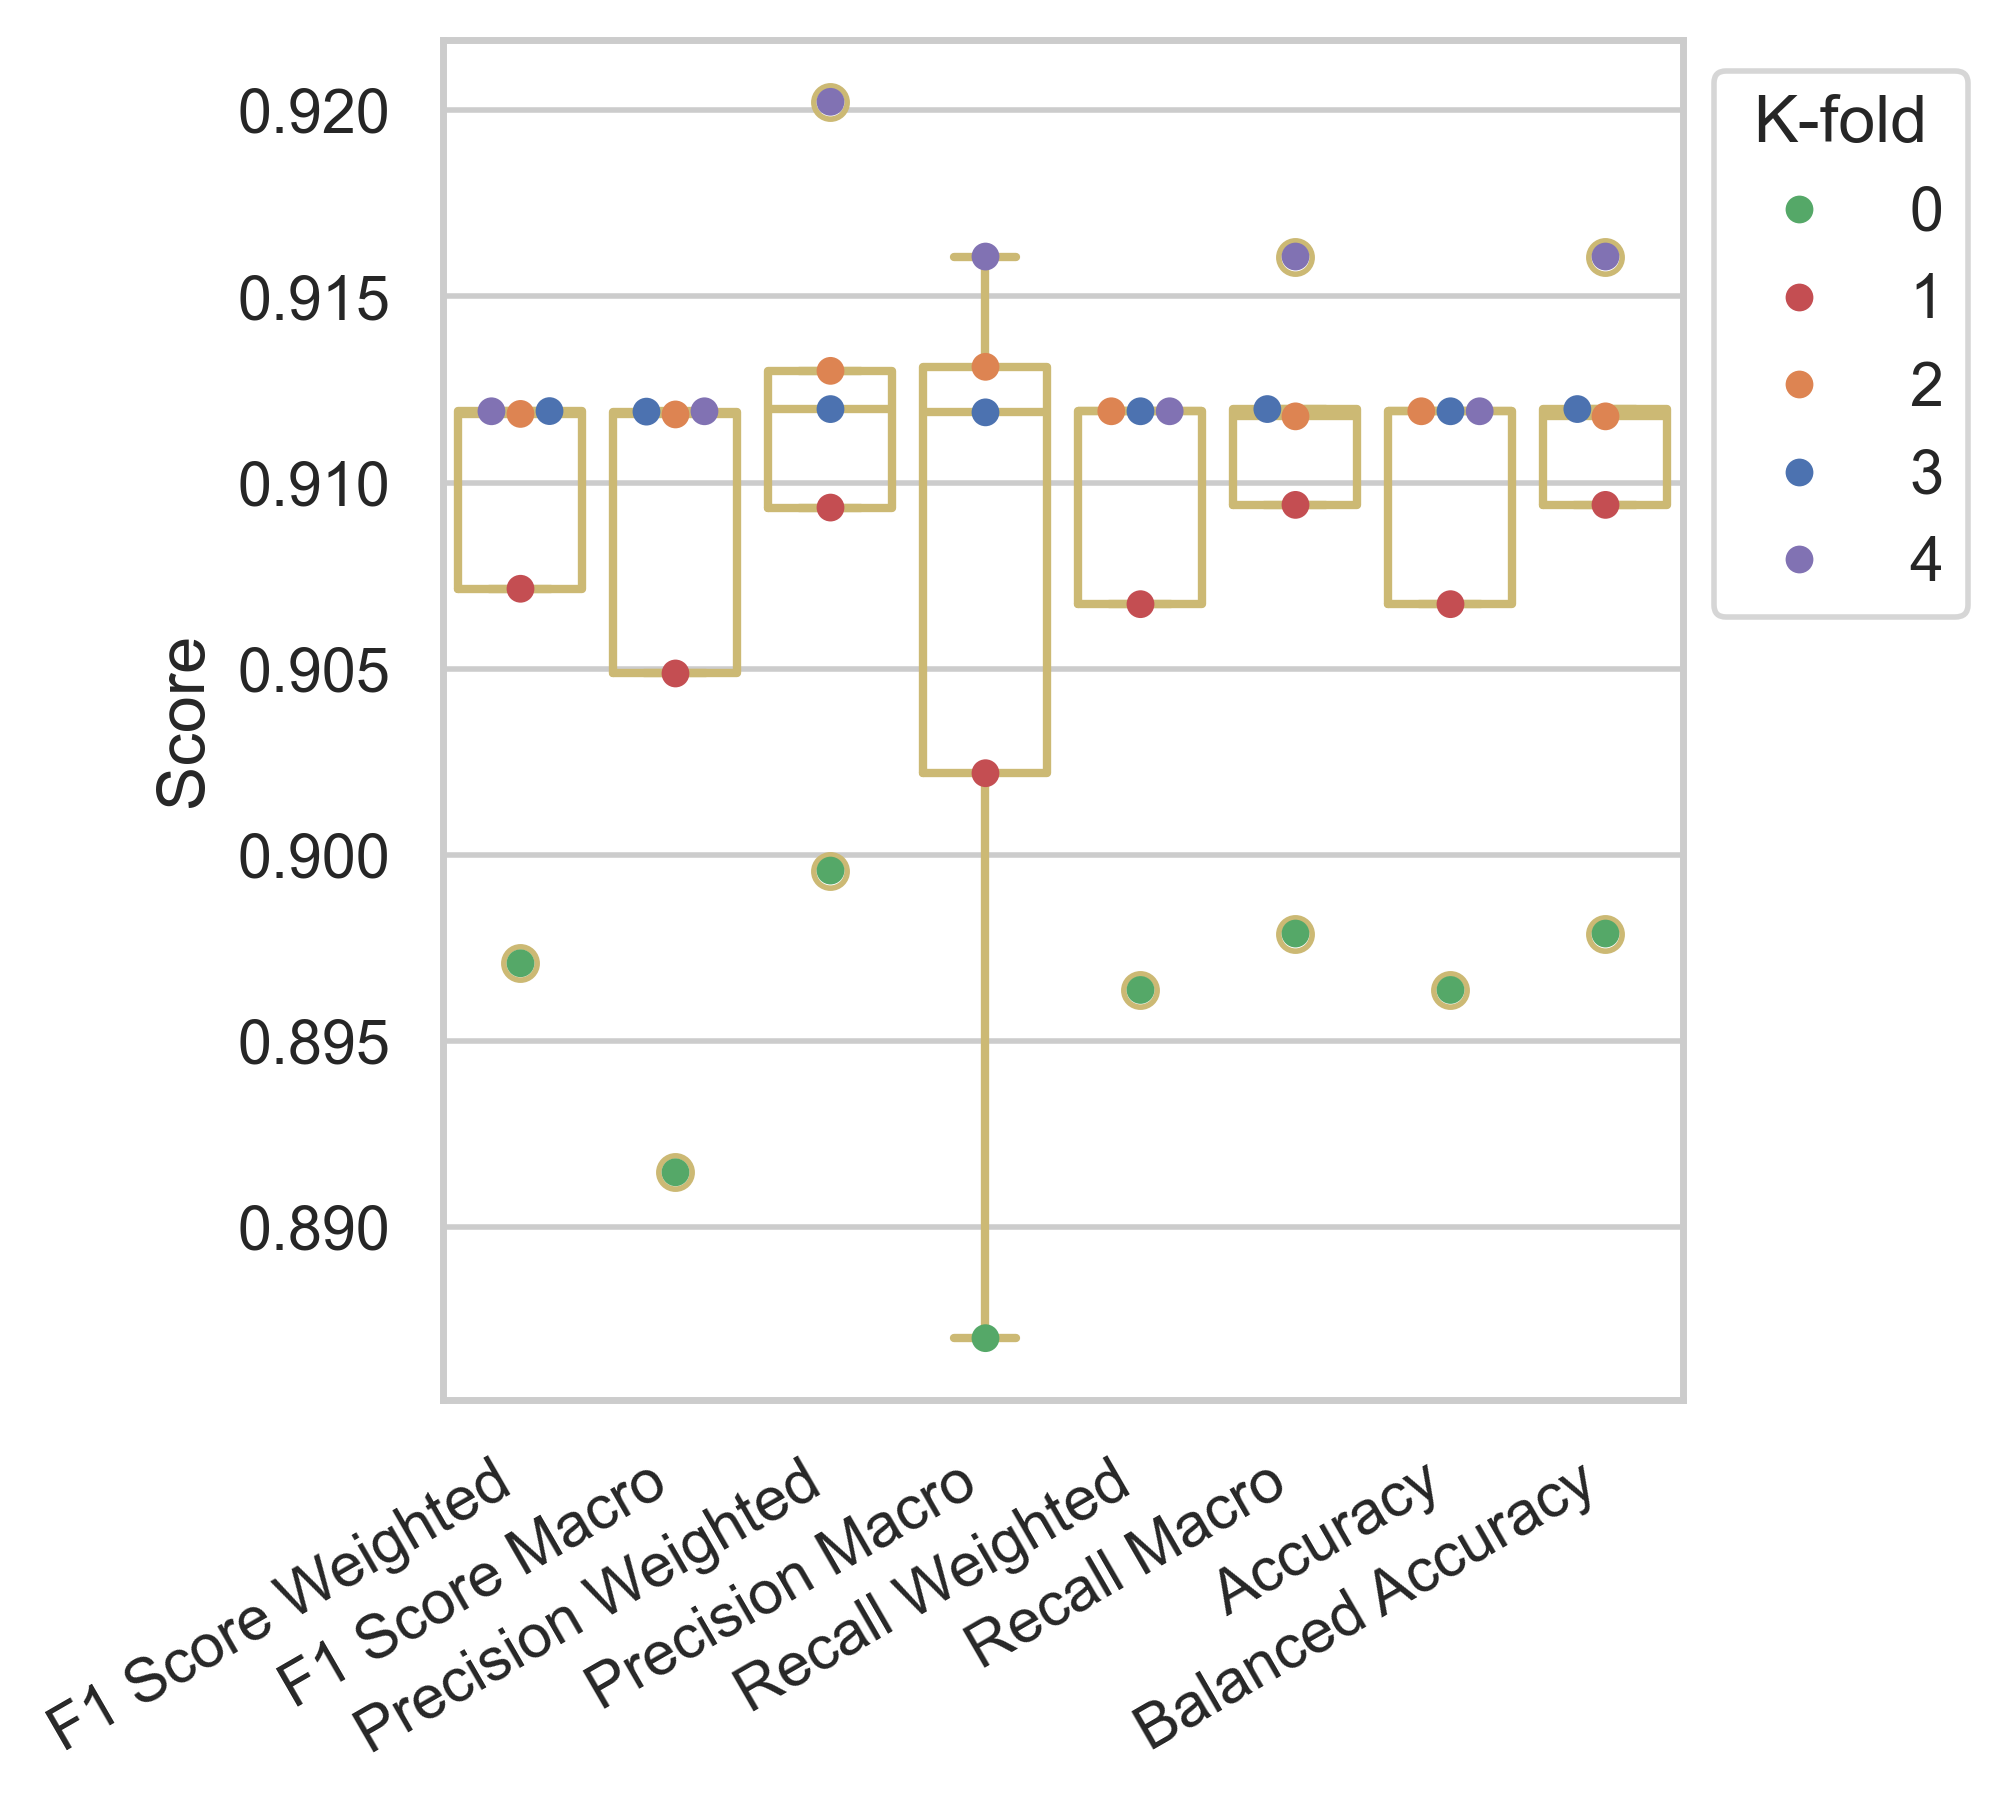

In [142]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(4, 5), dpi = 400)
df = df_baselines[df_baselines["model_name"] == "HistGradientBoosting"]
df = df[df["kmer_suffix_size"] == 8]



df_long = (
    df.reset_index()
    .melt(
        id_vars = ["index", "seed","model_name"],
        value_vars=["f1_score_weighted","f1_score_macro","precision_weighted","precision_macro",
                "recall_weighted","recall_macro","accuracy","balanced_accuracy"],
        var_name = "score_type",
        value_name="score")
    )


ax = sns.swarmplot(data = df_long, x= "score_type", y = "score", hue = "seed")
ax = sns.boxplot(data=df_long, x= "score_type", y = "score",fill=False)
#
# ax.set_title('Balanced accuracy for Gentamicin Resistance Prediction Task')
ax.set_ylabel('Score')
ax.set_xlabel(None)


handles, labels = ax.get_legend_handles_labels()
# sort both labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
ax.legend(handles, labels,bbox_to_anchor=(1, 1), title = "K-fold")

plt.gcf().autofmt_xdate()
new_labels = [
    lbl.get_text().replace("_", " ").title()
    for lbl in ax.get_xticklabels()
]

ax = ax.set_xticklabels(new_labels)
#plt.tight_layout()
#plt.savefig("file.jpeg", edgecolor='black', dpi=400, facecolor='black', transparent=True)
#ax.set_xlabel('Model architecture')
# Color 

float(df.iloc[0]["balanced_accuracy"])=0.9160733549083063, conf=[[88, 2], [15, 88]]


<Axes: title={'center': 'Confusion matrix for HistGradientBoosting - task: Resistant Phenotype'}>

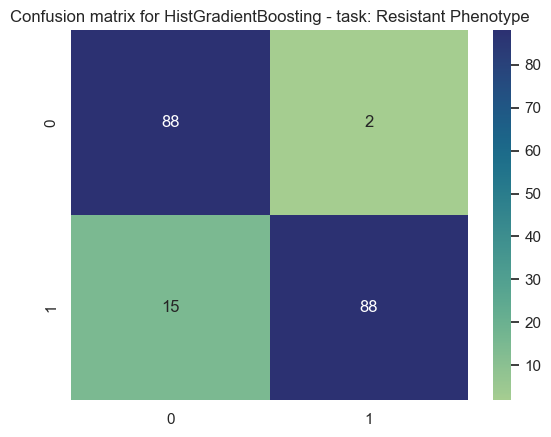

In [18]:
confusion_plot(path = "../results/AMR_gentamicin/baselines/feature_extraction/ungrouped_09_12_25/tmp_result_frequency_HistGradientBoosting_resistant_phenotype_ATG_8_4.csv")